# Phase 7 — Model Evaluation
Deep evaluation of XGBoost (best model, R²=0.5633) and formal comparison across all models.

**Steps:**
1. Re-train all 4 models
2. Formal comparison table (R², MAE, RMSE — train & test)
3. XGBoost residual plots — where does it break down?
4. Learning curves — diagnose overfitting/underfitting
5. Subgroup error analysis — by Region, Role, Experience band
6. Identify where the model underperforms

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load Data

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()
cleaned = pd.read_csv('../data/cleaned.csv', low_memory=False)

# Fix EdLevel NaN
median_ed = X_train['EdLevel_ord'].median()
X_train['EdLevel_ord'] = X_train['EdLevel_ord'].fillna(median_ed)
X_test['EdLevel_ord']  = X_test['EdLevel_ord'].fillna(median_ed)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (14143, 136) | X_test: (3536, 136)


## Re-train All Models

In [3]:
lr    = LinearRegression()
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100, 500, 1000], cv=5)
lasso = LassoCV(cv=5, max_iter=5000, random_state=42)
xgb   = XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=20, eval_metric='rmse', verbosity=0,
)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print('All models trained.')
print(f'Ridge best alpha : {ridge.alpha_}')
print(f'Lasso best alpha : {lasso.alpha_:.6f}')
print(f'XGBoost best iter: {xgb.best_iteration}')

All models trained.
Ridge best alpha : 10.0
Lasso best alpha : 0.002468
XGBoost best iter: 278


## 7.1 — Formal Comparison Table

In [4]:
def metrics(model, X, y):
    yp  = model.predict(X)
    r2  = r2_score(y, yp)
    mae = mean_absolute_error(np.expm1(y), np.expm1(yp))
    rmse= np.sqrt(mean_squared_error(np.expm1(y), np.expm1(yp)))
    return r2, mae, rmse

rows = []
for name, mdl in [('Linear Regression', lr), ('Ridge', ridge), ('Lasso', lasso), ('XGBoost', xgb)]:
    tr2, tmae, trmse = metrics(mdl, X_train, y_train)
    er2, emae, ermse = metrics(mdl, X_test,  y_test)
    rows.append(dict(Model=name,
                     R2_train=tr2, R2_test=er2,
                     MAE_train=tmae, MAE_test=emae,
                     RMSE_train=trmse, RMSE_test=ermse))

cmp = pd.DataFrame(rows)
fmt = cmp.copy()
for c in ['R2_train','R2_test']:
    fmt[c] = fmt[c].apply(lambda x: f'{x:.4f}')
for c in ['MAE_train','MAE_test','RMSE_train','RMSE_test']:
    fmt[c] = fmt[c].apply(lambda x: f'${x:,.0f}')
print(fmt.to_string(index=False))

            Model R2_train R2_test MAE_train MAE_test RMSE_train RMSE_test
Linear Regression   0.5123  0.5057   $34,500  $34,683    $53,803   $54,731
            Ridge   0.5123  0.5057   $34,502  $34,684    $53,833   $54,753
            Lasso   0.4938  0.4914   $35,099  $35,185    $54,915   $55,640
          XGBoost   0.6459  0.5633   $29,693  $32,370    $47,667   $52,123


## 7.2 — XGBoost Residual Analysis

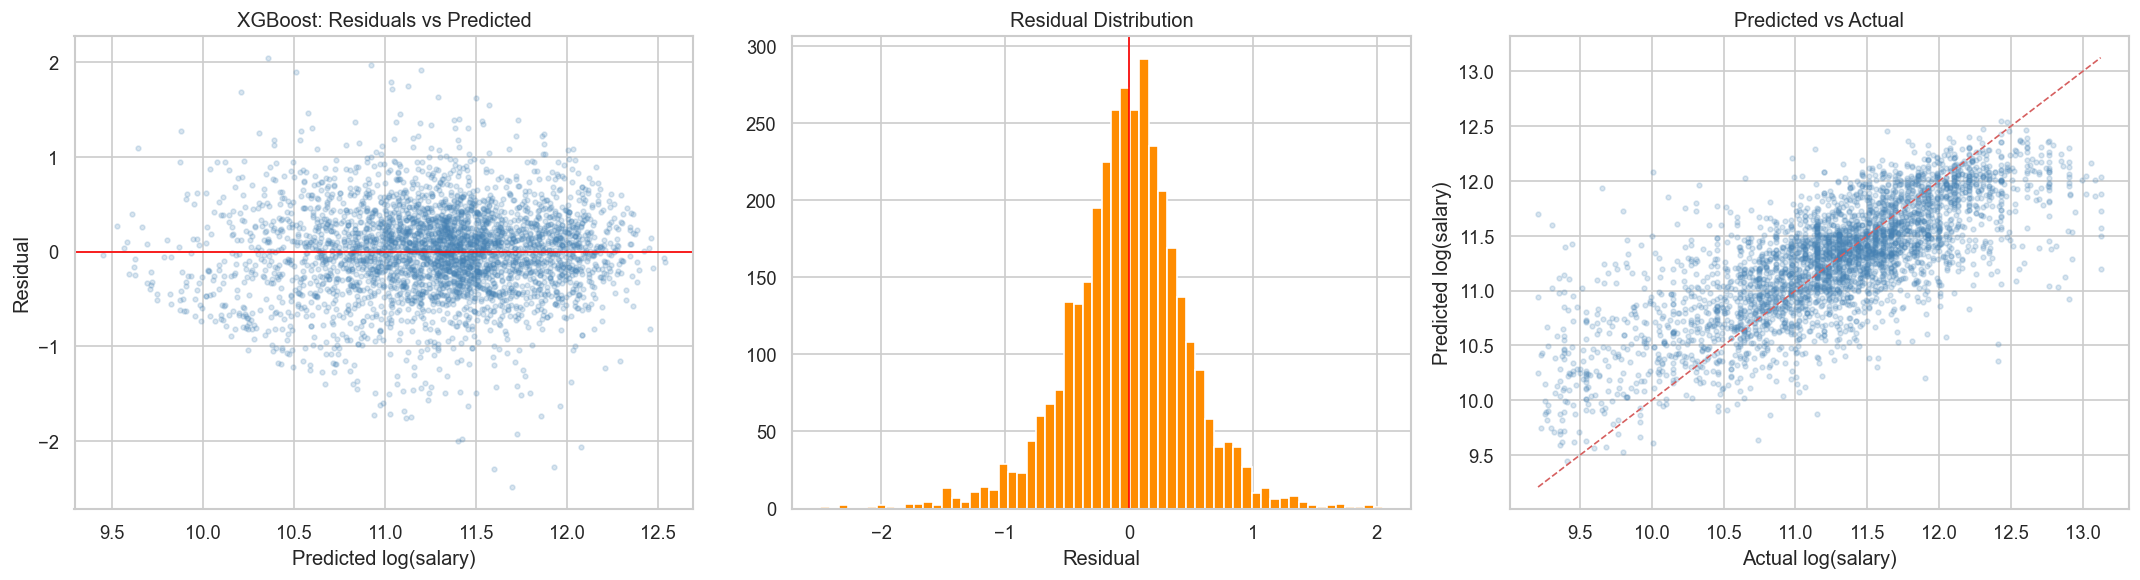

Residual mean : -0.0091
Residual std  : 0.4754
% within 0.5 log units: 76.2%
% within 1.0 log units: 95.5%


In [5]:
y_pred = xgb.predict(X_test)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('XGBoost: Residuals vs Predicted')
axes[0].set_xlabel('Predicted log(salary)')
axes[0].set_ylabel('Residual')

# Residual distribution
axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

# Predicted vs Actual
axes[2].scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1)
axes[2].set_title('Predicted vs Actual')
axes[2].set_xlabel('Actual log(salary)')
axes[2].set_ylabel('Predicted log(salary)')

plt.tight_layout()
plt.savefig('../reports/xgb_residuals.png', bbox_inches='tight')
plt.show()

print(f'Residual mean : {residuals.mean():.4f}')
print(f'Residual std  : {residuals.std():.4f}')
print(f'% within 0.5 log units: {(np.abs(residuals) < 0.5).mean()*100:.1f}%')
print(f'% within 1.0 log units: {(np.abs(residuals) < 1.0).mean()*100:.1f}%')

## 7.3 — Learning Curves (XGBoost)

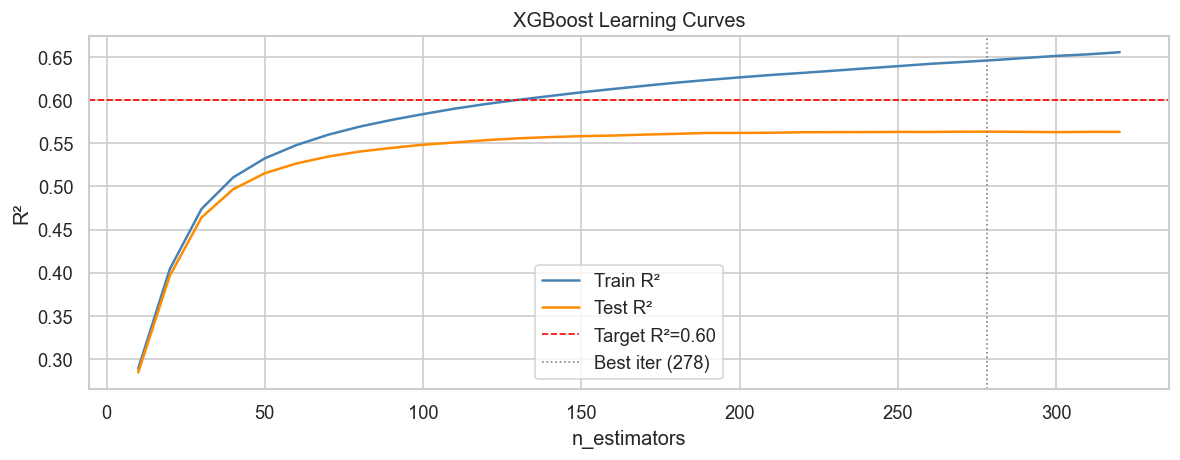

Max Train R²: 0.6553
Max Test  R²: 0.5633


In [6]:
# R² on train and test as n_estimators grows (sample every 10 rounds)
train_r2, test_r2 = [], []
steps = list(range(10, xgb.best_iteration + 50, 10))

for n in steps:
    xgb_n = XGBRegressor(
        n_estimators=n, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0,
    )
    xgb_n.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, xgb_n.predict(X_train)))
    test_r2.append(r2_score(y_test,  xgb_n.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, train_r2, label='Train R²', color='steelblue')
ax.plot(steps, test_r2,  label='Test R²',  color='darkorange')
ax.axhline(0.60, color='red', linestyle='--', linewidth=1, label='Target R²=0.60')
ax.axvline(xgb.best_iteration, color='grey', linestyle=':', linewidth=1, label=f'Best iter ({xgb.best_iteration})')
ax.set_title('XGBoost Learning Curves')
ax.set_xlabel('n_estimators')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/xgb_learning_curves.png', bbox_inches='tight')
plt.show()

print(f'Max Train R²: {max(train_r2):.4f}')
print(f'Max Test  R²: {max(test_r2):.4f}')

## 7.4 — Subgroup Error Analysis

In [7]:
# Build eval dataframe with predictions and metadata
eval_df = cleaned.iloc[y_test.index].copy().reset_index(drop=True)
eval_df['y_actual']  = y_test.values
eval_df['y_pred']    = y_pred
eval_df['residual']  = eval_df['y_actual'] - eval_df['y_pred']
eval_df['abs_error'] = eval_df['residual'].abs()

# Region column from features
region_cols = [c for c in X_test.columns if c.startswith('region_')]
region_arr  = X_test.iloc[y_test.index - y_test.index[0]].reset_index(drop=True)[region_cols]
eval_df['Region'] = region_arr.idxmax(axis=1).str.replace('region_', '')

# Experience band
bins   = [0, 2, 5, 10, 20, 50]
labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '21-50 yrs']
eval_df['ExpBand'] = pd.cut(eval_df['WorkExp'], bins=bins, labels=labels, right=True)

# Primary role
eval_df['PrimaryRole'] = eval_df['DevType'].str.split(';').str[0].str.strip()

In [8]:
# MAE by Region
region_err = (eval_df.groupby('Region')['abs_error']
              .agg(['mean','count'])
              .sort_values('mean', ascending=False))
region_err.columns = ['Mean Abs Error (log)', 'Count']
print('MAE by Region:')
print(region_err.to_string())

MAE by Region:
                    Mean Abs Error (log)  Count
Region                                         
Middle_East_Africa              0.650752     99
Other                           0.513148    103
East_SE_Asia                    0.487280     83
Latin_America                   0.485116    141
South_Asia                      0.430985    144
North_America                   0.346223   1052
Eastern_Europe                  0.341801    326
Western_Europe                  0.313054   1469
Oceania                         0.229507    119


In [9]:
# MAE by Experience Band
exp_err = (eval_df.groupby('ExpBand', observed=True)['abs_error']
           .agg(['mean','count'])
           .sort_values('mean', ascending=False))
exp_err.columns = ['Mean Abs Error (log)', 'Count']
print('MAE by Experience Band:')
print(exp_err.to_string())

MAE by Experience Band:
           Mean Abs Error (log)  Count
ExpBand                               
21-50 yrs              0.369631    825
11-20 yrs              0.352325   1191
6-10 yrs               0.348543    867
3-5 yrs                0.347989    468
0-2 yrs                0.331981    185


In [10]:
# MAE by Primary Role (top 10 worst)
role_err = (eval_df.groupby('PrimaryRole')['abs_error']
            .agg(['mean','count'])
            .query('count >= 30')
            .sort_values('mean', ascending=False))
role_err.columns = ['Mean Abs Error (log)', 'Count']
print('MAE by Role (worst → best, min 30 samples):')
print(role_err.head(15).to_string())

MAE by Role (worst → best, min 30 samples):
                                             Mean Abs Error (log)  Count
PrimaryRole                                                             
Cloud infrastructure engineer                            0.540052     54
Applied scientist                                        0.487143     32
AI/ML engineer                                           0.452296     51
Data or business analyst                                 0.416587     35
Data engineer                                            0.386165     66
Developer, embedded applications or devices              0.386133    120
Senior executive (C-suite, VP, etc.)                     0.381602     50
Developer, mobile                                        0.379221    101
Other (please specify):                                  0.378749    116
DevOps engineer or professional                          0.370892     96
Architect, software or solutions                         0.366279    245
Enginee

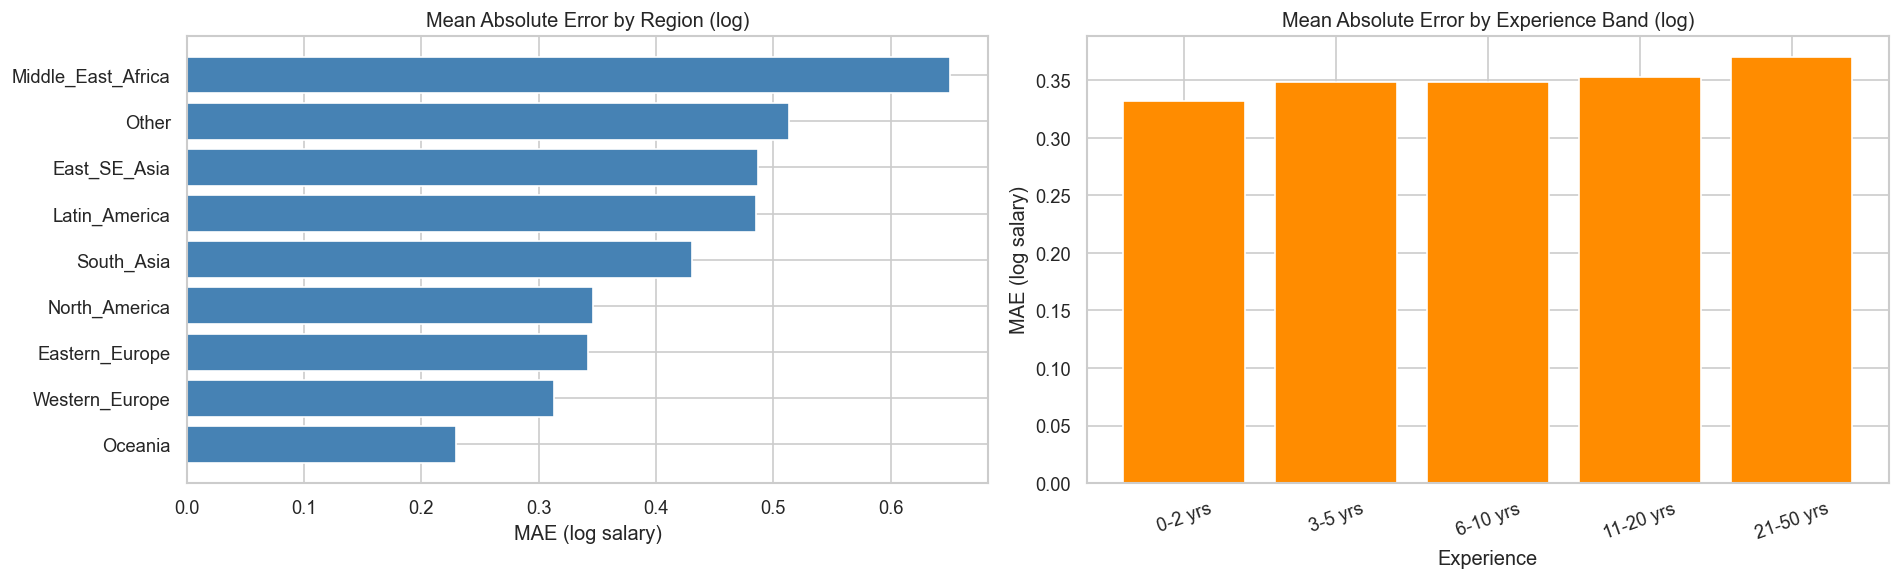

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Region error bars
region_err_plot = region_err.sort_values('Mean Abs Error (log)', ascending=True)
axes[0].barh(region_err_plot.index, region_err_plot['Mean Abs Error (log)'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Mean Absolute Error by Region (log)')
axes[0].set_xlabel('MAE (log salary)')

# Experience band error bars
exp_err_plot = eval_df.groupby('ExpBand', observed=True)['abs_error'].mean().sort_index()
axes[1].bar(exp_err_plot.index.astype(str), exp_err_plot.values,
            color='darkorange', edgecolor='white')
axes[1].set_title('Mean Absolute Error by Experience Band (log)')
axes[1].set_xlabel('Experience')
axes[1].set_ylabel('MAE (log salary)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../reports/subgroup_errors.png', bbox_inches='tight')
plt.show()

## Phase 7 Summary

**Formal Comparison (test set):**

| Model | R2 Train | R2 Test | MAE Train | MAE Test | RMSE Test |
|-------|----------|---------|-----------|----------|-----------|
| Linear Regression | 0.5123 | 0.5057 | $34,500 | $34,683 | $54,731 |
| Ridge | 0.5123 | 0.5057 | $34,502 | $34,684 | $54,753 |
| Lasso | 0.4938 | 0.4914 | $35,099 | $35,185 | $55,640 |
| **XGBoost** | **0.6459** | **0.5633** | **$29,693** | **$32,370** | **$52,123** |

**XGBoost Residuals:**
- Residual mean: -0.0091 (nearly unbiased) | std: 0.4754
- 76.2% of predictions within 0.5 log units (~$40k band at median)
- 95.5% of predictions within 1.0 log units

**Learning Curves:**
- Max Train R2: 0.6553 | Max Test R2: 0.5633
- Gap of ~0.09 between train and test indicates moderate overfitting -- XGBoost has learned some training noise

**Subgroup Analysis -- Where the model underperforms:**

By Region (worst to best MAE):
- Middle East/Africa: 0.651 (n=99) -- small sample, high salary variance
- Other: 0.513 (n=103) -- catch-all bucket, heterogeneous
- East/SE Asia: 0.487 (n=83) -- small sample
- Latin America: 0.485 (n=141)
- Best: Oceania 0.230, Western Europe 0.313, Eastern Europe 0.342

By Experience Band (worst to best MAE):
- 21-50 yrs: 0.370 -- senior devs have widest salary spread, hardest to predict
- 0-2 yrs: 0.332 -- junior devs are most predictable

By Role (worst, min 30 samples):
- Cloud infrastructure engineer: 0.540 (n=54)
- Applied scientist: 0.487 (n=32)
- AI/ML engineer: 0.452 (n=51)
- Developer, full-stack: 0.339 (n=1,111) -- most predictable (largest group)

**Key conclusions:**
- XGBoost is the best model but falls short of the 0.60 R2 target on test
- Model predicts most accurately for Western Europe, Eastern Europe, and Oceania
- Hardest subgroups: Middle East/Africa, niche roles (Cloud Infra, Applied Scientist, AI/ML)
- SHAP analysis in Phase 8 will give a cleaner picture of which features drive these errors